In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

def kde_g(X, h = 0.0, plot = True):
    X = np.array(X)
    gauss = lambda z: np.exp( -z**2 / 2) / np.sqrt(2 * np.pi) 
    n = len(X)
    if h == 0.0:
        h = 1.06 * X.std() * n ** (-0.2) 
        print(f'Plug-in Bandwidth Estimated is: {h:2f}')
    x_grid = np.linspace( X.min()-2*h, X.max()+2*h, 100)
    K = gauss( (x_grid[:,None] - X[None,:])/h)/h 
    f_hat = K.mean(axis=1)
    if plot:
        plt.plot(x_grid,f_hat)
        plt.title('KDE Estimator')
        plt.show()
    return x_grid, f_hat, h


[Text(0.5, 1.0, 'Gaussian KDE (Smooth)')]

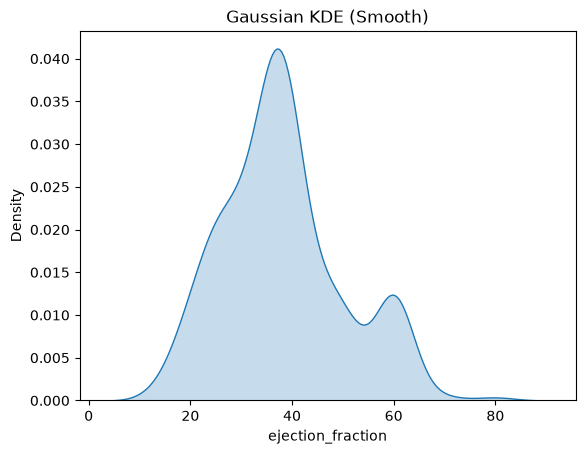

In [2]:
# Part A
sns.kdeplot(data = df, x = 'ejection_fraction', fill = True).set(title='Gaussian KDE (Smooth)')

Plug-in Bandwidth Estimated is: 3.992006
Plug-in Bandwidth Estimated is: 4.123925
Plug-in Bandwidth Estimated is: 4.190776
Plug-in Bandwidth Estimated is: 3.954915
Plug-in Bandwidth Estimated is: 3.864771
Plug-in Bandwidth Estimated is: 3.857771
Plug-in Bandwidth Estimated is: 4.086342
Plug-in Bandwidth Estimated is: 3.680307
Plug-in Bandwidth Estimated is: 3.738896
Plug-in Bandwidth Estimated is: 3.897422
Plug-in Bandwidth Estimated is: 4.024216
Plug-in Bandwidth Estimated is: 4.164917
Plug-in Bandwidth Estimated is: 3.991826
Plug-in Bandwidth Estimated is: 3.771626
Plug-in Bandwidth Estimated is: 3.994813


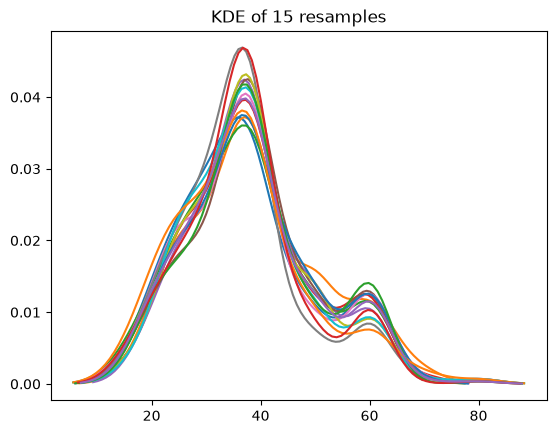

In [3]:
# Part B

for i in range(15):
    boot = df.sample(frac=1.0, replace=True)
    x_grid_b, f_hat_b, h_b = kde_g(boot['ejection_fraction'], plot=False)
    plt.plot(x_grid_b, f_hat_b)
plt.title('KDE of 15 resamples')
plt.show()
